In [5]:
# %%
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_validate, train_test_split

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración.
"""

sys.path.append(os.path.abspath(".."))

In [6]:
data_train = pd.read_csv(
    "../../../dataset/Spotify_train_preprocesado_regresion.csv"
)

data_test = pd.read_csv(
    "../../../dataset/Spotify_test_preprocesado_regresion.csv"
)

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento:")
display(df_train.head())

print("\nDataset de prueba:")
display(df_test.head())

Dataset de entrenamiento:


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,1.037180,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,21.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,0.475025,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,1.037180,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,45.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,1.599335,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,4.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,-1.211439,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,55.0



Dataset de prueba:


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,0.756103,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,-0.368207,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,0.475025,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,7.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,0.475025,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,23.0
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,0.475025,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0.0


In [7]:
# Separación de variables predictoras y objetivo
X_train = df_train.drop(
    columns=["popularity"]
)

y_train = df_train[
    "popularity"
]

X_test = df_test.drop(
    columns=["popularity"]
)

y_test = df_test[
    "popularity"
]

In [8]:
# Selección de una muestra del conjunto de entrenamiento
X_train_svr, _, y_train_svr, _ = train_test_split(
    X_train,
    y_train,
    train_size=5000,
    random_state=42
)

print("Registros originales:", len(X_train))
print("Registros seleccionados:", len(X_train_svr))
print("Dimensiones de X_train_svr:", X_train_svr.shape)
print("Dimensiones de y_train_svr:", y_train_svr.shape)

Registros originales: 90737
Registros seleccionados: 5000
Dimensiones de X_train_svr: (5000, 20)
Dimensiones de y_train_svr: (5000,)


In [10]:
# %%
modelo_svr = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1,
    gamma="scale",
    cache_size=1000
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

resultados_cv = cross_validate(
    modelo_svr,
    X_train_svr,
    y_train_svr,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

resultados_svr = {
    "MAE": -resultados_cv["test_mae"].mean(),
    "MSE": -resultados_cv["test_mse"].mean(),
    "RMSE": -resultados_cv["test_rmse"].mean(),
    "R2": resultados_cv["test_r2"].mean()
}

desviaciones_svr = {
    "MAE": resultados_cv["test_mae"].std(),
    "MSE": resultados_cv["test_mse"].std(),
    "RMSE": resultados_cv["test_rmse"].std(),
    "R2": resultados_cv["test_r2"].std()
}

print("Resultados de Support Vector Regression:")

for metrica, valor in resultados_svr.items():
    print(f"{metrica}: {valor:.4f}")

print("\nDesviación estándar entre particiones:")

for metrica, valor in desviaciones_svr.items():
    print(f"{metrica}: {valor:.4f}")

Resultados de Support Vector Regression:
MAE: 16.6156
MSE: 444.4290
RMSE: 21.0799
R2: 0.1090

Desviación estándar entre particiones:
MAE: 0.1932
MSE: 10.8018
RMSE: 0.2547
R2: 0.0273


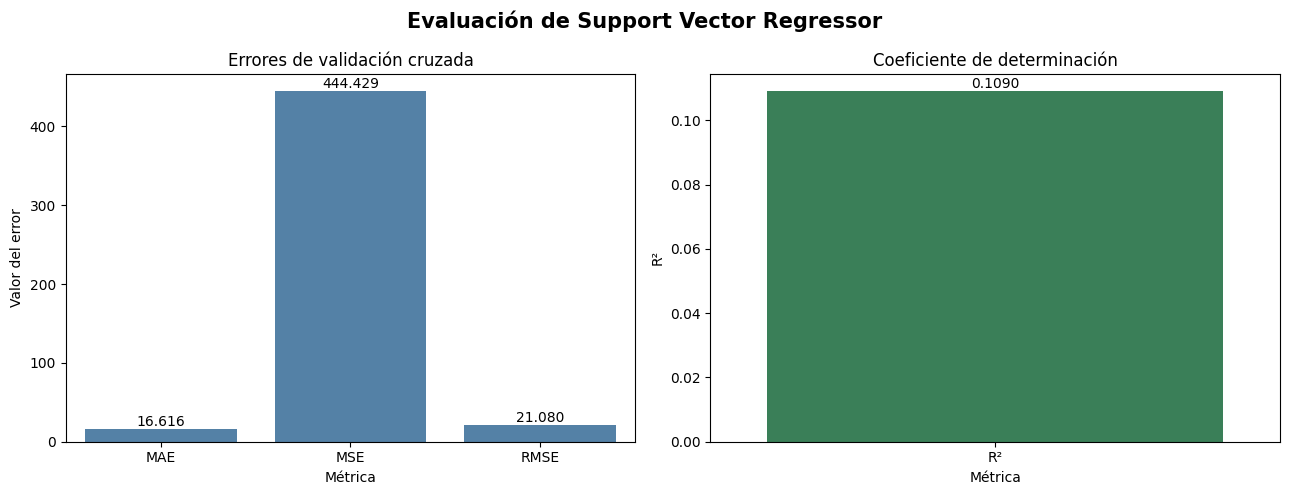

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metricas_error = ["MAE", "MSE", "RMSE"]

valores_error = [
    resultados_svr[m]
    for m in metricas_error
]

sns.barplot(
    x=metricas_error,
    y=valores_error,
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Errores de validación cruzada")
axes[0].set_xlabel("Métrica")
axes[0].set_ylabel("Valor del error")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f")

sns.barplot(
    x=["R²"],
    y=[resultados_svr["R2"]],
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title("Coeficiente de determinación")
axes[1].set_xlabel("Métrica")
axes[1].set_ylabel("R²")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f")

plt.suptitle(
    "Evaluación de Support Vector Regressor",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [15]:
modelo_svr.fit(
    X_train_svr,
    y_train_svr
)

y_pred_svr = modelo_svr.predict(X_test)

# Métricas de evaluación
mae_test = mean_absolute_error(y_test, y_pred_svr)
mse_test = mean_squared_error(y_test, y_pred_svr)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_svr)

resultados_svr_test = {
    "MAE": mae_test,
    "MSE": mse_test,
    "RMSE": rmse_test,
    "R2": r2_test
}

print("Resultados de SVR en prueba:")

for metrica, valor in resultados_svr_test.items():
    print(f"{metrica}: {valor:.4f}")

print(f"Registros evaluados: {len(X_test)}")

Resultados de SVR en prueba:
MAE: 16.4016
MSE: 439.1399
RMSE: 20.9557
R2: 0.1137
Registros evaluados: 22685


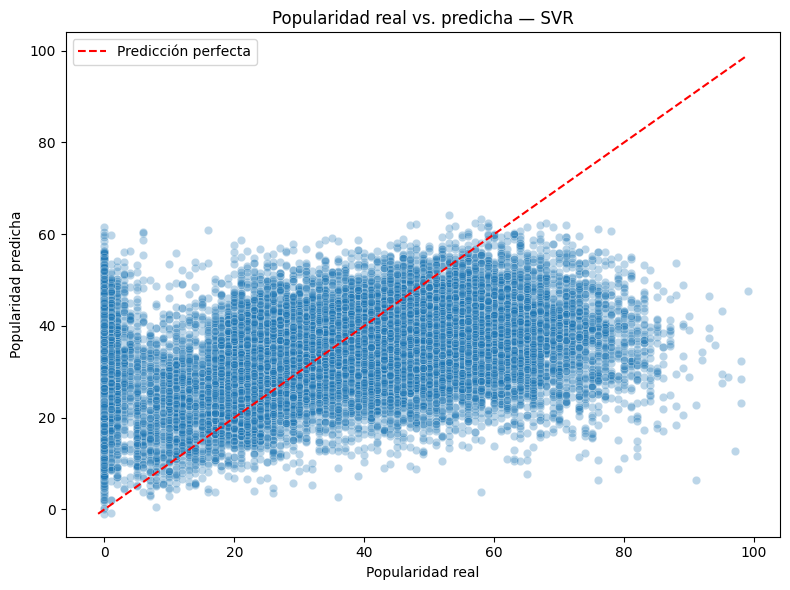

In [16]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_svr,
    alpha=0.3
)

limite_min = min(y_test.min(), y_pred_svr.min())
limite_max = max(y_test.max(), y_pred_svr.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.title("Popularidad real vs. predicha — SVR")
plt.xlabel("Popularidad real")
plt.ylabel("Popularidad predicha")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:

# Cantidad de filas para calcular la importancia por permutación
n_importancia = min(len(X_train_svr), len(X_test))

# Seleccionar una muestra del conjunto de prueba
X_test_importancia = X_test.sample(
    n=n_importancia,
    random_state=42
)

# Obtener los valores reales correspondientes
y_test_importancia = y_test.loc[X_test_importancia.index]

# Calcular la importancia por permutación
resultado_permutacion = permutation_importance(
    modelo_svr,
    X_test_importancia,
    y_test_importancia,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=42,
    n_jobs=1
)

# Crear DataFrame con las importancias
importancias_svr = pd.DataFrame({
    "Variable": X_test_importancia.columns,
    "Importancia": resultado_permutacion.importances_mean,
    "Desviacion": resultado_permutacion.importances_std
}).sort_values(
    by="Importancia",
    ascending=False
)

display(importancias_svr.head(15))


,Variable,Importancia,Desviacion
8,num__danceability,0.771496,0.062557
2,bin__track_genre_2,0.722013,0.048898
15,num__instrumentalness,0.402010,0.031766
5,bin__track_genre_5,0.367688,0.025839
14,num__acousticness,0.361934,0.057576
17,num__valence,0.355262,0.023120
19,num__duration_min,0.344964,0.025935
11,num__loudness,0.320395,0.039506
3,bin__track_genre_3,0.319982,0.025400
13,num__speechiness,0.299659,0.020238


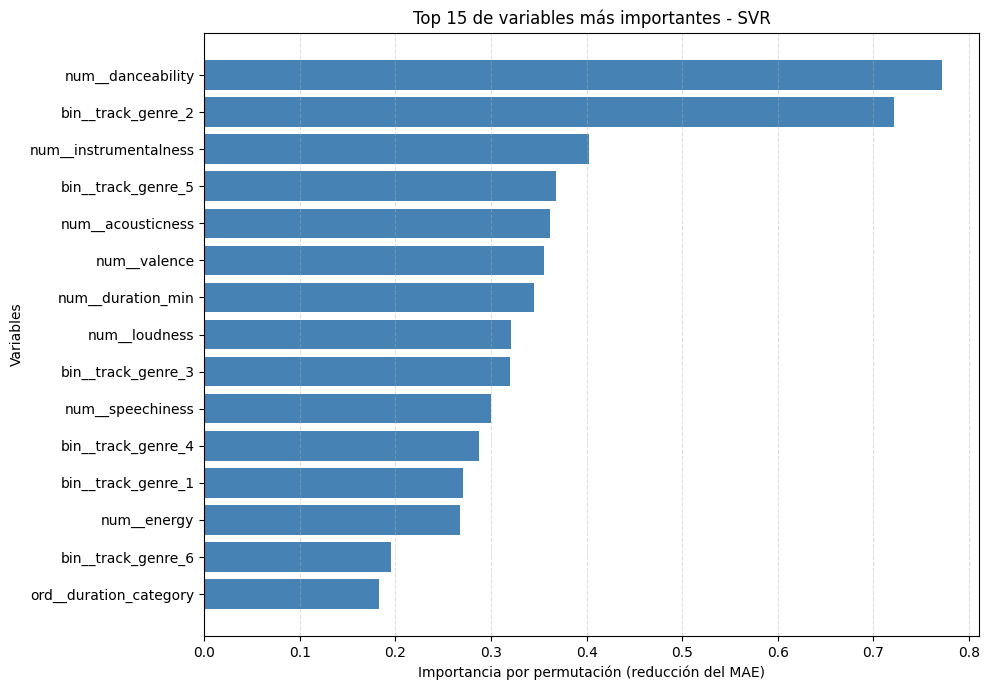

In [ ]:
# Seleccionar las 15 variables más importantes
top_15 = importancias_svr.head(15).sort_values(
    by="Importancia",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15["Variable"],
    top_15["Importancia"],
    color="steelblue",
    capsize=3
)

plt.title("Top 15 de variables más importantes - SVR")
plt.xlabel("Importancia por permutación (reducción del MAE)")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()